In [1]:
using NeutralAtoms


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
include("../conf/configs_gen.jl")
cfg_CZ = get_6P_config();
cfg_CZ.n_samples = 1;
cfg_CZ.atom_params[2] = 100.0;

In [3]:
ρ_mean = simulation_czlp(cfg_CZ)[1][end] ; 

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:26<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:26<Inf:Inf, InfGs/it]


1.627 0.03894506851622437


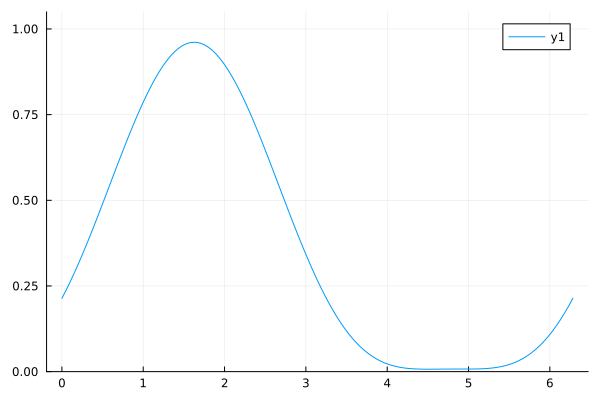

In [4]:
using Plots
#ϕ_list = [0.0:0.001:2π;];
#F_list = [get_fidelity_phi(ρ, cfg_CZ.ψ0, ϕ) for ϕ in ϕ_list]
ϕ_list, F_list, ϕ_cal = get_fidelity_phi(ρ_mean, cfg_CZ.ψ0, 0)
println(ϕ_cal, " ", 1-maximum(F_list))
plot(ϕ_list, F_list, ylims=(0.0,1.05))

In [15]:
"""using Plots
ϕ_list, F_list, ϕ_cal = get_fidelity_osc(ρ, cfg_CZ.ψ0)
println(ϕ_cal, " ", 1-maximum(F_list))
plot(ϕ_list, F_list, ylims=(0.0,1.05))"""
θ = ϕ_cal
cfg_CZ.ϕ_RZ # + ϕ_cal - π
for θ in 0:π/10:2π
    ϕ_list, P_list = get_parity_osc(ρ_mean, θ)
    println(maximum(P_list))
    plot!(ϕ_list, P_list, ylims=(-1.05,1.05)) 
end; 

0.9818843302337008
0.9809748600399283
0.9803328772277246
0.9796882240201638
0.9789680878239057
0.9781573975676393
0.9778348865509039
0.9786679417684149
0.9795749701316276
0.9805156386241053
0.9814168433588228
0.9821844625147274
0.9827438909478943
0.9830683870099236
0.9831770413443353
0.9831147932110428
0.9829258207156545
0.9826469088651065
0.9823036287342399
0.9819245199501067
0.9818843302337008


##Моделирование##

Основной атом

In [ ]:
using NeutralAtoms
include("../default.jl")
_, cfg_CZ = get_default_configs();
c_xy = get_default_cxy(); #c_xy = get_ideal_cxy();

In [19]:
cfg_CZ.blue_laser_params["type"] = "flattop" #"gauss" #
cfg_CZ.blue_laser_params["coeffs_xy"] = c_xy; 
cfg_CZ.blue_laser_params;

In [3]:
m = 86.9091835;     
T = 0.1; #70.0 #0.01 #

ket_pos = (ket_0 + ket_1) / sqrt(2)
ket_neg = (ket_0 - ket_1) / sqrt(2)

cfg_CZ.n_samples = 1#00 #50 # 50
cfg_CZ.atom_params = [m, T];
cfg_CZ.spontaneous_decay_intermediate = true #true; # 
cfg_CZ.spontaneous_decay_rydberg = true #true; # 
println(cfg_CZ.atom_params[2], " ",  cfg_CZ.detuning_params[1]/2π)

0.1 1710.9999999999998


0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:26<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:26<Inf:Inf, InfGs/it]


2.1882 0.008049630488006554 0.0051417595687871884


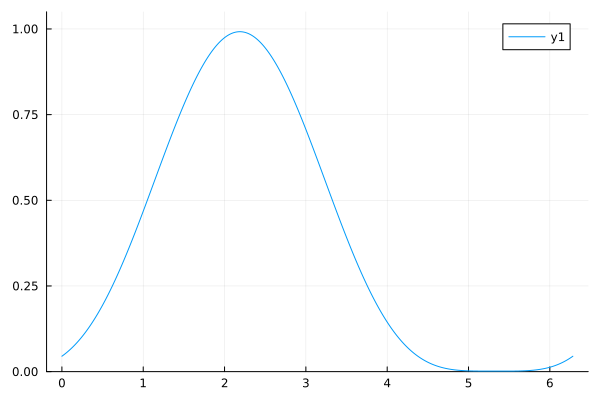

In [10]:
using Plots
ϕ_list, F_list, ϕ_cal, pr = get_p_prob_and_fid(cfg_CZ)

println(ϕ_cal, " ", 1-maximum(F_list), " ", pr) 
plot(ϕ_list, F_list, ylims=(0.0,1.05))

In [62]:
Id = ket_0 ⊗ dagger(ket_0) + ket_1 ⊗ dagger(ket_1) + ket_p ⊗ dagger(ket_p) + ket_r ⊗ dagger(ket_r) + ket_l ⊗ dagger(ket_l);
Had = Id ⊗ (ket_0 ⊗ dagger(ket_0) - ket_1 ⊗ dagger(ket_1) + ket_0 ⊗ dagger(ket_1) + ket_1 ⊗ dagger(ket_0))/sqrt(2)
RZ = θ -> (exp(-1.0im*θ/2)*(ket_0 ⊗ dagger(ket_0)) +  exp(1.0im*θ/2)*(ket_1 ⊗ dagger(ket_1)));
ϕ = 2.189  #6.184  #1.878
glrz = RZ(ϕ) ⊗ RZ(ϕ);

In [63]:
pr_m = ket_neg ⊗ dagger(ket_neg)
pr_p = ket_pos ⊗ dagger(ket_pos);
pr_0 = ket_0 ⊗ dagger(ket_0)
pr_1 = ket_1 ⊗ dagger(ket_1);
#projs = [pr_p ⊗ pr_p, pr_p ⊗ pr_m, pr_m ⊗ pr_p, pr_m ⊗ pr_m];
projs = [pr_0 ⊗ pr_0, pr_0 ⊗ pr_1, pr_1 ⊗ pr_0, pr_1 ⊗ pr_1];
states = [ket_0 ⊗ ket_0, ket_0 ⊗ ket_1, ket_1 ⊗ ket_0, ket_1 ⊗ ket_1];

In [64]:
for state in states 
    cfg_CZ.ψ0 = Had * state #(ket_1 ⊗ ket_pos
    ρ_end = simulation_czlp(cfg_CZ)[1][end] ; #_rec2d
    ρ = Had*glrz * ρ_end * dagger(Had*glrz);
    pr_s = [round(real(expect(proj, ρ)); digits=6) for proj in projs] 
    println(pr_s)
end

0.0%┣                                              ┫ 0/200 [00:00<00:00, -0s/it]
0.5%┣▏                                         ┫ 1/200 [00:12<Inf:Inf, InfGs/it]
1.0%┣▍                                          ┫ 2/200 [00:24<01:20:37, 24s/it]
1.5%┣▊                                             ┫ 3/200 [00:37<59:58, 18s/it]
2.0%┣█                                             ┫ 4/200 [00:49<53:03, 16s/it]
2.5%┣█▏                                            ┫ 5/200 [01:01<49:25, 15s/it]
3.0%┣█▍                                            ┫ 6/200 [01:13<47:11, 15s/it]
3.5%┣█▋                                            ┫ 7/200 [01:25<45:37, 14s/it]
4.0%┣█▉                                            ┫ 8/200 [01:37<44:26, 14s/it]
4.5%┣██                                            ┫ 9/200 [01:49<43:27, 14s/it]
5.0%┣██▎                                          ┫ 10/200 [02:01<42:37, 13s/it]
5.5%┣██▌                                          ┫ 11/200 [02:13<41:53, 13s/it]
6.0%┣██▊                    

[0.844726, 0.130912, 0.0, 0.0]


100.0%┣██████████████████████████████████████████┫ 200/200 [40:40<00:00, 12s/it]
100.0%┣██████████████████████████████████████████┫ 200/200 [40:40<00:00, 12s/it]
0.0%┣                                              ┫ 0/200 [00:00<00:00, -0s/it]
0.5%┣▏                                         ┫ 1/200 [00:12<Inf:Inf, InfGs/it]
1.0%┣▍                                          ┫ 2/200 [00:24<01:20:34, 24s/it]
1.5%┣▋                                          ┫ 3/200 [00:37<01:00:41, 18s/it]
2.0%┣█                                             ┫ 4/200 [00:49<53:27, 16s/it]
2.5%┣█▏                                            ┫ 5/200 [01:01<49:36, 15s/it]
3.0%┣█▍                                            ┫ 6/200 [01:13<47:18, 15s/it]
3.5%┣█▋                                            ┫ 7/200 [01:25<45:39, 14s/it]
4.0%┣█▉                                            ┫ 8/200 [01:37<44:21, 14s/it]
4.5%┣██                                            ┫ 9/200 [01:49<43:19, 14s/it]
5.0%┣██▎                    

[0.128208, 0.849793, 0.0, 0.0]


100.0%┣███████████████████████████████████████┫ 200/200 [01:10:09<00:00, 21s/it]
100.0%┣███████████████████████████████████████┫ 200/200 [01:10:09<00:00, 21s/it]
0.0%┣                                              ┫ 0/200 [00:00<00:00, -0s/it]
0.5%┣▏                                         ┫ 1/200 [00:16<Inf:Inf, InfGs/it]
1.0%┣▍                                          ┫ 2/200 [00:31<01:42:24, 31s/it]
1.5%┣▋                                          ┫ 3/200 [00:46<01:14:49, 23s/it]
2.0%┣▉                                          ┫ 4/200 [01:00<01:05:47, 20s/it]
2.5%┣█                                          ┫ 5/200 [01:16<01:01:38, 19s/it]
3.0%┣█▍                                            ┫ 6/200 [01:31<58:52, 18s/it]
3.5%┣█▋                                            ┫ 7/200 [01:46<56:48, 18s/it]
4.0%┣█▉                                            ┫ 8/200 [02:01<55:25, 17s/it]
4.5%┣██                                            ┫ 9/200 [02:17<54:22, 17s/it]
5.0%┣██▎                    

[0.005359, 0.004335, 0.17974, 0.651094]


100.0%┣██████████████████████████████████████████┫ 200/200 [51:53<00:00, 16s/it]
100.0%┣██████████████████████████████████████████┫ 200/200 [51:53<00:00, 16s/it]
0.0%┣                                              ┫ 0/200 [00:00<00:00, -0s/it]
0.5%┣▏                                         ┫ 1/200 [00:16<Inf:Inf, InfGs/it]
1.0%┣▍                                          ┫ 2/200 [00:31<01:43:35, 31s/it]
1.5%┣▋                                          ┫ 3/200 [00:48<01:19:08, 24s/it]
2.0%┣▉                                          ┫ 4/200 [01:05<01:10:42, 22s/it]
2.5%┣█                                          ┫ 5/200 [01:21<01:05:46, 20s/it]
3.0%┣█▎                                         ┫ 6/200 [01:37<01:02:43, 19s/it]
3.5%┣█▌                                         ┫ 7/200 [01:53<01:00:39, 19s/it]
4.0%┣█▉                                            ┫ 8/200 [02:08<58:42, 18s/it]
4.5%┣██                                            ┫ 9/200 [02:24<57:23, 18s/it]
5.0%┣██▎                    

[0.00429, 0.00549, 0.669625, 0.157988]


100.0%┣██████████████████████████████████████████┫ 200/200 [51:56<00:00, 16s/it]
100.0%┣██████████████████████████████████████████┫ 200/200 [51:56<00:00, 16s/it]


In [38]:
ρ_mean = simulation_czlp(cfg_CZ)[1][end] ; 
"""using Plots
ϕ_list, F_list, ϕ_cal = get_fidelity_osc(ρ, cfg_CZ.ψ0)
println(ϕ_cal, " ", 1-maximum(F_list))
plot(ϕ_list, F_list, ylims=(0.0,1.05))"""

0.0%┣                                                ┫ 0/1 [00:00<00:00, -0s/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:26<Inf:Inf, InfGs/it]
100.0%┣██████████████████████████████████████████┫ 1/1 [00:26<Inf:Inf, InfGs/it]


"using Plots\nϕ_list, F_list, ϕ_cal = get_fidelity_osc(ρ, cfg_CZ.ψ0)\nprintln(ϕ_cal, \" \", 1-maximum(F_list))\nplot(ϕ_list, F_list, ylims=(0.0,1.05))"

In [49]:
θ = ϕ_cal
cfg_CZ.ϕ_RZ # + ϕ_cal - π

0.04913661748510334

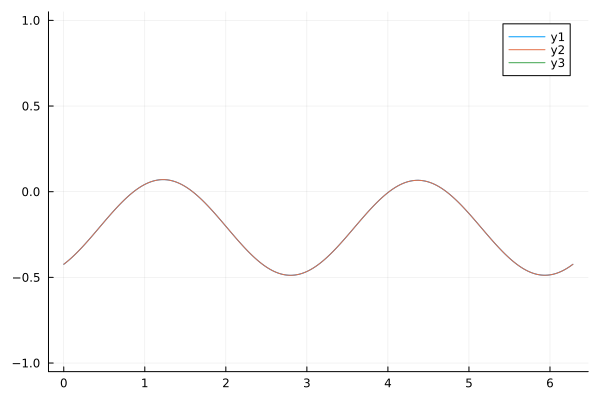

In [60]:
plot!([0.0],[0.0])

In [ ]:
for θ in 0:π/10:2π
    ϕ_list, P_list = get_parity_osc(ρ_mean, θ)
    println(maximum(P_list))
    plot!(ϕ_list, P_list, ylims=(-1.05,1.05)) 
end; 

0.07057157535812895
0.01829053287658989
0.009230521018674873
0.046386543065060695
0.11810055578884408
0.20709696686982826
0.2976468808217798
0.3777669622137393
0.439250113734191
0.4777825762509956
0.49513459923739334
0.4989929135237624
0.4990842759217317
0.4976527047481621
0.4867241637196976
0.4570132654460151
0.4044091102234617
0.33070198617439023
0.24263470092366685
0.15108096482243982
0.0705715753581289


In [38]:
ws = vcat(1.4:0.1:2.5, 2.6:0.2:3.2)

16-element Vector{Float64}:
 1.4
 1.5
 1.6
 1.7
 1.8
 1.9
 2.0
 2.1
 2.2
 2.3
 2.4
 2.5
 2.6
 2.8
 3.0
 3.2

In [10]:
include("../default.jl")
cfg_CZ_2gauss = get_default_cfg2gauss(4.0);
cfg_CZ_2gauss.blue_laser_params 

Dict{String, Any} with 12 entries:
  "z1"            => 6.61388
  "w1"            => 4.0
  "beams_centers" => [[0.0, 1.7, 0.0], [0.0, -1.7, 0.0]]
  "rel_phase"     => 0.0
  "n_sg"          => 1
  "z"             => 6.61388
  "Ω1"            => 192.05
  "z0"            => 26.4555
  "θ"             => 0.0
  "w0"            => 2.0
  "Ω"             => 192.05
  "type"          => "2gauss"

In [31]:
using Plots
m = 86.9091835; 
T = 100.1 #100.0;
cfg_CZ_2gauss.atom_params = [m, T]
cfg_CZ_2gauss.n_samples = 100; #0; #50 # 50
cfg_CZ_2gauss.spontaneous_decay_intermediate = true #true; #
cfg_CZ_2gauss.spontaneous_decay_rydberg = true #true; #
println(cfg_CZ_2gauss.atom_params[2], " ", cfg_CZ_2gauss.detuning_params[1]/2π)

100.1 1710.9999999999998


In [98]:
plot([0.0],[0.0]) #, ylims=(0.95,1.02), xlims=(1.6,1.8)) #, ylabel="Field phase", xlabel="z coord");
Ω

287.70540174118423

In [99]:
#ws = 0.5:0.5:4.0
ws = [2.2] #vcat(0.4:0.2:2.0, 2.5:0.5:3.0)
xx = -5.0:0.01:5.0
Fids = []
z0 = cfg_CZ_2gauss.blue_laser_params["z0"]; 
w0 = cfg_CZ_2gauss.blue_laser_params["w0"];
ϕ0 = cfg_CZ_2gauss.blue_laser_params["rel_phase"];
#ϕ_list = 0:π/10:2π
for w in ws
    #for ϕ in ϕ_list
    cfg_CZ_2gauss.blue_laser_params["w0"] = w
    cfg_CZ_2gauss.blue_laser_params["w1"] = w
    cfg_CZ_2gauss.blue_laser_params["z0"] = z0*(w0/w)^2
    cfg_CZ_2gauss.blue_laser_params["z1"] = z0*(w0/w)^2
    cfg_CZ_2gauss.blue_laser_params["rel_phase"] = ϕ0
    cfg_CZ_2gauss.blue_laser_params["Ω"] = 1.0 * Ω*corr_om(ϕ0,1.7+1.7,w,z0*(w0/w)^2)
    cfg_CZ_2gauss.blue_laser_params["Ω1"] = 1.0 * Ω*corr_om(ϕ0,-1.7-1.7,w,z0*(w0/w)^2)

    ρ_2gauss, _ = simulation_czlp(cfg_CZ_2gauss) ; 
    ϕ_list, F_list, ϕ_cal = get_fidelity_osc(ρ_2gauss[end], cfg_CZ_2gauss.ψ0) 
    println(w , " ", maximum(F_list), " ", ϕ_cal)
    push!(Fids, maximum(F_list))
    plot!(ϕ_list, F_list, ylims=(0.0,1.05), label = "$w") 
    #E = [abs(gauss_field(0.0,x-1.7,0.0, w, z0*(w0/w)^2) + exp(1.0im*ϕ0) * gauss_field(0.0,1.7+x,0.0, w, z0*(w0/w)^2)) for x in xx]
    #plot!(xx, E .* corr_om(ϕ0,1.7+1.7,w,z0*(w0/w)^2),  label = "$w")
    #E = [angle(gauss_field(0.5,-0.5,x, w, z0*(w0/w)^2) + exp(1.0im*ϕ) * gauss_field(0.5,2.9,x, w, z0*(w0/w)^2)) for x in xx]
    #plot!(xx, E,  label = "$(round(w;digits=2))")
    
end;

0.0%┣                                              ┫ 0/100 [00:00<00:00, -0s/it]
1.0%┣▍                                         ┫ 1/100 [00:13<Inf:Inf, InfGs/it]
2.0%┣█                                             ┫ 2/100 [00:26<42:38, 26s/it]
3.0%┣█▍                                            ┫ 3/100 [00:39<31:35, 20s/it]
4.0%┣█▉                                            ┫ 4/100 [00:53<28:09, 18s/it]
5.0%┣██▎                                           ┫ 5/100 [01:10<27:41, 17s/it]
6.0%┣██▊                                           ┫ 6/100 [01:33<29:03, 19s/it]
7.0%┣███▏                                          ┫ 7/100 [01:48<27:57, 18s/it]
8.0%┣███▊                                          ┫ 8/100 [02:24<31:32, 21s/it]
9.0%┣████▏                                         ┫ 9/100 [02:41<30:33, 20s/it]
10.0%┣████▍                                       ┫ 10/100 [02:54<29:01, 19s/it]
11.0%┣████▉                                       ┫ 11/100 [03:07<27:48, 19s/it]
12.0%┣█████▎                

2.2 0.8329965477690413 5.914


100.0%┣██████████████████████████████████████████┫ 100/100 [38:25<00:00, 23s/it]
100.0%┣██████████████████████████████████████████┫ 100/100 [38:25<00:00, 23s/it]


In [100]:
1.0.-Fids

1-element Vector{Float64}:
 0.1670034522309587

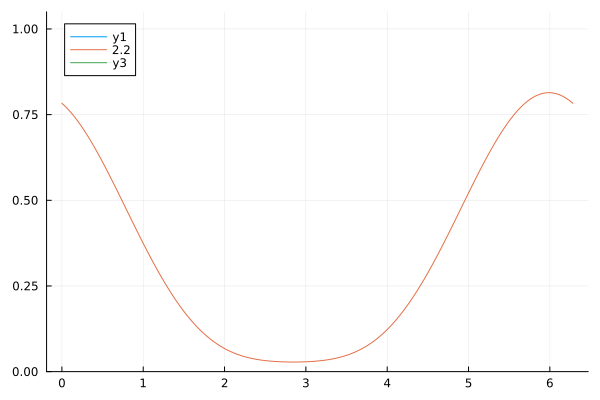

In [58]:
plot!([0.0],[0.0])

In [62]:
#ϕ_list = 0:π/10:2π #phase btwn gausses"
1.0.-Fids

1-element Vector{Float64}:
 0.18606014660275694

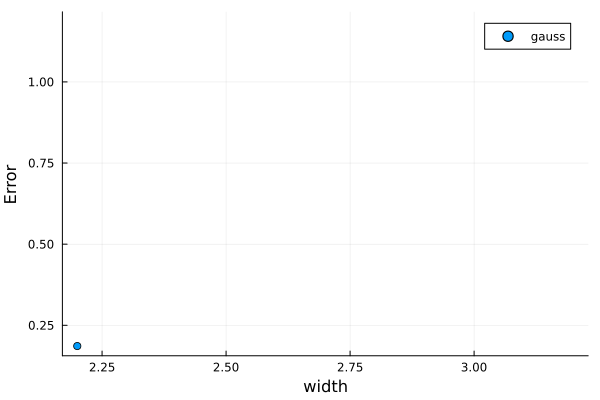

In [60]:
scatter(ws, 1.0 .- Fids, ylabel="Error", xlabel="width", label="gauss")#, ylims=(0.64,0.9))
#plot!([0.5,5.0],[0.8763, 0.8763], label="flattop")

In [ ]:
E = [abs(gauss_field(0.0,x-1.7,0.0, w, z0*(w0/w)^2) + exp(1.0im*ϕ0) * gauss_field(0.0,1.7+x,0.0, w, z0*(w0/w)^2)) for x in xx]
    plot!(xx, E .* corr_om(ϕ0,1.7+1.7,w,z0*(w0/w)^2),  label = "$w")

In [92]:
Fids

Any[]

In [ ]:
using Plots

ρ_flat, _ = simulation_czlp_rec2d(c_xy, cfg_CZ_gauss) ; 

ϕ_list, F_list, ϕ_cal = get_fidelity_osc(ρ_flat[end], cfg_CZ_gauss.ψ0)
println(ϕ_cal, " ", maximum(F_list))
plot(ϕ_list, F_list, ylims=(0.0,1.05), label = "flat") 
#0.8763422149764433

In [ ]:

5.5 0.8760982537681716
5 0.8597335564401196
4.5  0.8130290296167957 ????
4 0.800232788018761
3.5 0.7705629983362954
3 0.69

In [51]:
θ = -cfg_CZ_gauss.ϕ_RZ + ϕ_cal - π - 1 #0.95

-2.6297292710748965

In [ ]:
#θ = -cfg_CZ_gauss.ϕ_RZ + ϕ_cal - π
ϕ_list, P_list = get_parity_osc(ρ_gauss[end], θ)
plot(ϕ_list, P_list, ylims=(-1.05,1.05)) 

In [24]:
"""
data = DataFrame(    Column1 = cfg.tspan,    Column2 = Pr_HG)
CSV.write("output.csv", data)
plot(cfg.tspan, Pr_HG) """  

"data = DataFrame(    Column1 = cfg.tspan,    Column2 = Pr_HG)\nCSV.write(\"output.csv\", data)\nplot(cfg.tspan, Pr_HG) "